# Quantium Virtual Internship – Task 2
# Experimentation and Trial Store Assessment

**Prepared by:** HASIB SHAIKH

---

## Objective

The objective of this analysis is to evaluate the effectiveness of the new store layout trial implemented in Stores **77**, **86**, and **88**. The analysis compares each trial store with a carefully selected control store using historical sales performance and customer purchasing behaviour.

The assessment focuses on:

- Identifying suitable control stores based on pre-trial performance.
- Comparing trial and control stores during the trial period.
- Evaluating whether changes in sales are statistically significant.
- Understanding the drivers of sales performance.
- Providing recommendations on whether the new layout should be rolled out to other stores.

## Step 1: Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, and statistical analysis.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import t

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

The cleaned transaction dataset generated from Task 1 is loaded into the notebook for further analysis.

In [4]:
df=pd.read_csv(r"D:\Downloads\QVI_data.csv")

In [5]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [8]:
df.shape

(264834, 12)

In [10]:
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [11]:
df.duplicated().sum()

1

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


### Observation

The dataset has been successfully loaded.

It contains transaction-level information including:

- LyLTY_CARD_NUMBER
- TXN_ID
- Store Number
- Transaction Date
- Product Information
- Quantity Purchased
- Total Sales
- Customer Segment
- Premium Customer Category

The dataset is clean and ready for analysis.

## Step 3: Convert the Date Column

To perform monthly trend analysis, the `DATE` column must be converted into a datetime format.

Once converted, additional time-based features such as **Year** and **Month** can be extracted to support the comparison of trial and control stores over time.

In [12]:
df["DATE"].head(10)

0    2018-10-17
1    2018-09-16
2    2019-03-07
3    2019-03-08
4    2018-11-02
5    2018-12-28
6    2018-12-04
7    2018-12-05
8    2018-11-20
9    2018-09-09
Name: DATE, dtype: object

In [13]:

df["DATE"] = pd.to_datetime(df["DATE"])


print(df["DATE"].dtype)


df[["DATE"]].head()

datetime64[ns]


,DATE
0,2018-10-17
1,2018-09-16
2,2019-03-07
3,2019-03-08
4,2018-11-02


### Observation

The `DATE` column has been successfully converted to the datetime format.

This allows us to perform time-based analysis such as monthly sales trends and customer behaviour over different periods.

## Step 4: Create Monthly Features

To compare store performance over time, monthly features are created from the transaction date.

The analysis will use **Year-Month** as the primary time period for aggregating sales and customer metrics.

In [15]:
# Create Year, Month and Year-Month columns
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["YEAR_MONTH"] = df["DATE"].dt.to_period("M")

# Preview the new columns
df[["DATE", "YEAR", "MONTH", "YEAR_MONTH"]].head()

,DATE,YEAR,MONTH,YEAR_MONTH
0,2018-10-17,2018,10,2018-10
1,2018-09-16,2018,9,2018-09
2,2019-03-07,2019,3,2019-03
3,2019-03-08,2019,3,2019-03
4,2018-11-02,2018,11,2018-11


### Observation

Three new time-related features were created:

- **YEAR** – Transaction year
- **MONTH** – Transaction month
- **YEAR_MONTH** – Combined year and month used for monthly aggregation

These variables will be used throughout the analysis to compare trial and control stores on a monthly basis.

# Step 5: Create Monthly Store Performance Metrics

To compare trial stores with potential control stores, the transaction-level data is aggregated into **monthly store-level metrics**.

The following key performance indicators (KPIs) are calculated for each store every month:

- **Total Sales Revenue**
- **Number of Unique Customers**
- **Number of Transactions**
- **Average Transactions per Customer**
- **Average Units Purchased per Customer**
- **Average Price per Unit**

These metrics will be used to identify suitable control stores and evaluate the effectiveness of the trial stores.

In [16]:
# Create monthly store performance metrics

monthly_metrics = (
    df.groupby(["STORE_NBR", "YEAR_MONTH"])
      .agg(
          TOTAL_SALES=("TOT_SALES", "sum"),
          TOTAL_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
          TOTAL_TRANSACTIONS=("TXN_ID", "nunique"),
          TOTAL_QTY=("PROD_QTY", "sum")
      )
      .reset_index()
)

In [17]:
# Average transactions per customer
monthly_metrics["AVG_TXN_PER_CUSTOMER"] = (
    monthly_metrics["TOTAL_TRANSACTIONS"] /
    monthly_metrics["TOTAL_CUSTOMERS"]
)

# Average chips purchased per customer
monthly_metrics["AVG_CHIPS_PER_CUSTOMER"] = (
    monthly_metrics["TOTAL_QTY"] /
    monthly_metrics["TOTAL_CUSTOMERS"]
)

# Average price per unit
monthly_metrics["AVG_PRICE_PER_UNIT"] = (
    monthly_metrics["TOTAL_SALES"] /
    monthly_metrics["TOTAL_QTY"]
)

In [18]:
monthly_metrics.head()

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TRANSACTIONS,TOTAL_QTY,AVG_TXN_PER_CUSTOMER,AVG_CHIPS_PER_CUSTOMER,AVG_PRICE_PER_UNIT
0,1,2018-07,206.9,49,52,62,1.061224,1.265306,3.337097
1,1,2018-08,176.1,42,43,54,1.023810,1.285714,3.261111
2,1,2018-09,278.8,59,62,75,1.050847,1.271186,3.717333
3,1,2018-10,188.1,44,45,58,1.022727,1.318182,3.243103
4,1,2018-11,192.6,46,47,57,1.021739,1.239130,3.378947


In [19]:
monthly_metrics.shape

(3169, 9)

In [20]:
monthly_metrics.describe()

,STORE_NBR,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TRANSACTIONS,TOTAL_QTY,AVG_TXN_PER_CUSTOMER,AVG_CHIPS_PER_CUSTOMER,AVG_PRICE_PER_UNIT
count,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000
mean,136.802461,610.007889,69.826128,83.031556,159.269170,1.141307,2.088247,3.805827
std,78.418604,389.699478,36.817352,47.918428,100.476057,0.111341,0.468967,0.494938
min,1.000000,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,68.000000,260.000000,41.000000,43.000000,70.000000,1.041667,1.775510,3.447368
50%,137.000000,674.600000,79.000000,96.000000,182.000000,1.125000,2.188679,3.589524
75%,204.000000,928.200000,102.000000,127.000000,252.000000,1.233645,2.468085,4.365546
max,272.000000,1659.600000,150.000000,188.000000,377.000000,1.468085,3.021277,5.350000


### Observation

The transaction-level dataset has been successfully transformed into a monthly store-level dataset.

Each row now represents the monthly performance of a store and includes key business metrics such as sales revenue, customer count, transaction count, purchasing behaviour, and average selling price.

These monthly metrics provide a standardized basis for comparing the performance of trial stores with potential control stores.

# Step 6: Validate Monthly Store Data

Before selecting control stores, it is important to verify that each store has complete monthly data throughout the analysis period.

Stores with missing months cannot be reliably compared with trial stores and will therefore be excluded from the control store selection process.

In [21]:
# Count number of months available for each store

store_month_counts = (
    monthly_metrics.groupby("STORE_NBR")["YEAR_MONTH"]
    .nunique()
    .reset_index(name="MONTH_COUNT")
)

store_month_counts.head()

,STORE_NBR,MONTH_COUNT
0,1,12
1,2,12
2,3,12
3,4,12
4,5,12


In [22]:
store_month_counts["MONTH_COUNT"].value_counts().sort_index()

MONTH_COUNT
1       3
2       5
3       1
11      3
12    260
Name: count, dtype: int64

### Observation

The monthly data availability was checked for every store.

Only stores with a complete history across all months will be considered during the control store selection process. This ensures a fair comparison between trial and control stores.

# Step 7: Filter Stores with Complete Monthly Data

To ensure a fair comparison, only stores with data available for all **12 months** are retained.

Stores with incomplete transaction history are excluded because missing months can affect similarity calculations and lead to unreliable control store selection.

In [23]:
# Stores with complete 12 months of data
complete_stores = store_month_counts[
    store_month_counts["MONTH_COUNT"] == 12
]["STORE_NBR"]

# Keep only complete stores
monthly_metrics = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin(complete_stores)
]

print(monthly_metrics.shape)

(3120, 9)


### Observation

Only stores with complete monthly data were retained for further analysis.

After filtering, the dataset contains **260 stores**, each with a full 12-month history, ensuring consistency during the control store selection process.

# Step 8: Define the Pre-Trial and Trial Periods

To identify suitable control stores, only data from the **pre-trial period** is used. This ensures that the comparison is based on historical performance before any trial intervention.

The analysis periods are defined as:

- **Pre-Trial Period:** February 2018 to January 2019
- **Trial Period:** February 2019 to April 2019

The pre-trial data will be used to identify control stores, while the trial period will be used to evaluate the impact of the new store layout.

In [24]:
# Check available months in the dataset
sorted(monthly_metrics["YEAR_MONTH"].unique())

[Period('2018-07', 'M'),
 Period('2018-08', 'M'),
 Period('2018-09', 'M'),
 Period('2018-10', 'M'),
 Period('2018-11', 'M'),
 Period('2018-12', 'M'),
 Period('2019-01', 'M'),
 Period('2019-02', 'M'),
 Period('2019-03', 'M'),
 Period('2019-04', 'M'),
 Period('2019-05', 'M'),
 Period('2019-06', 'M')]

# Step 8: Define the Analysis Period

To identify suitable control stores, only the **pre-trial period** is used. This ensures that the control stores are selected based on historical performance before the trial began.

The analysis period is divided into:

- **Pre-Trial Period:** July 2018 – January 2019
- **Trial Period:** February 2019 – April 2019
- **Post-Trial Period:** May 2019 – June 2019

The pre-trial data will be used to identify similar control stores, while the trial period will be used to evaluate the impact of the new store layout.

In [25]:
# Pre-trial period
pre_trial = monthly_metrics[
    monthly_metrics["YEAR_MONTH"] < "2019-02"
].copy()

# Trial period
trial_period = monthly_metrics[
    (monthly_metrics["YEAR_MONTH"] >= "2019-02") &
    (monthly_metrics["YEAR_MONTH"] <= "2019-04")
].copy()

# Post-trial period
post_trial = monthly_metrics[
    monthly_metrics["YEAR_MONTH"] > "2019-04"
].copy()

In [26]:
print("Pre-Trial Shape :", pre_trial.shape)
print("Trial Shape     :", trial_period.shape)
print("Post-Trial Shape:", post_trial.shape)

Pre-Trial Shape : (1820, 9)
Trial Shape     : (780, 9)
Post-Trial Shape: (520, 9)


### Observation

The dataset has been divided into three analysis periods.

The **pre-trial period** will be used to identify suitable control stores, ensuring that comparisons are based on historical performance before the trial intervention.

The **trial period** will be used to evaluate whether the new store layout had a significant impact on store performance.

The **post-trial period** is retained for completeness but is not used during the initial assessment.

# Step 9: Identify Suitable Control Stores

The objective of this step is to identify a suitable **control store** for each trial store.

A good control store should behave similarly to the trial store **before the trial began**.

Two similarity measures are used:

- **Pearson Correlation** – compares the monthly trend between stores.
- **Magnitude Similarity** – compares the actual values of the selected metric.

The control store with the highest combined similarity score will be selected for each trial store.

## 9.1 Pearson Correlation Function

Pearson Correlation measures how closely two stores move together over time.

A correlation close to **1** indicates that both stores follow very similar monthly trends.

In [27]:
def calculate_correlation(input_table, metric, trial_store):
    """
    Calculate Pearson correlation between the trial store
    and every other store for a selected metric.
    """

    pivot_df = input_table.pivot(
        index="YEAR_MONTH",
        columns="STORE_NBR",
        values=metric
    )

    trial_series = pivot_df[trial_store]

    correlation = pivot_df.corrwith(trial_series)

    correlation = (
        correlation
        .reset_index()
        .rename(columns={0: "Correlation"})
    )

    correlation["Trial_Store"] = trial_store

    return correlation

## 9.2 Magnitude Similarity Function

While correlation measures similarity in trends, magnitude similarity compares the actual values.

Stores with similar sales values receive higher similarity scores.

In [28]:
def calculate_magnitude_distance(input_table, metric, trial_store):
    """
    Calculate magnitude similarity between
    trial store and all other stores.
    """

    pivot_df = input_table.pivot(
        index="YEAR_MONTH",
        columns="STORE_NBR",
        values=metric
    )

    trial_series = pivot_df[trial_store]

    distance = abs(pivot_df.subtract(trial_series, axis=0))

    distance = distance.sum()

    distance = (
        distance
        .reset_index()
        .rename(columns={0: "Distance"})
    )

    distance["Magnitude"] = (
        1 -
        (
            (distance["Distance"] - distance["Distance"].min()) /
            (distance["Distance"].max() - distance["Distance"].min())
        )
    )

    distance["Trial_Store"] = trial_store

    return distance[["STORE_NBR", "Magnitude", "Trial_Store"]]

## 9.3 Test the Similarity Functions

The functions are tested using **Store 77** based on **Total Sales** during the pre-trial period.

In [29]:
corr_sales_77 = calculate_correlation(
    pre_trial,
    "TOTAL_SALES",
    77
)

corr_sales_77.head()

,STORE_NBR,Correlation,Trial_Store
0,1,0.075218,77
1,2,-0.263079,77
2,3,0.806644,77
3,4,-0.263300,77
4,5,-0.110652,77


In [30]:
mag_sales_77 = calculate_magnitude_distance(
    pre_trial,
    "TOTAL_SALES",
    77
)

mag_sales_77.head()

,STORE_NBR,Magnitude,Trial_Store
0,1,0.950903,77
1,2,0.933198,77
2,3,0.317676,77
3,4,0.130226,77
4,5,0.526858,77


## 9.4 Combine Similarity Scores

The correlation score and magnitude similarity score are combined to calculate an overall similarity score.

The store with the highest score will be selected as the control store.

In [31]:
sales_similarity = corr_sales_77.merge(
    mag_sales_77,
    on=["STORE_NBR", "Trial_Store"]
)

sales_similarity["Final_Score"] = (
    sales_similarity["Correlation"] +
    sales_similarity["Magnitude"]
) / 2

sales_similarity = sales_similarity.sort_values(
    by="Final_Score",
    ascending=False
)

sales_similarity.head(10)

,STORE_NBR,Correlation,Trial_Store,Magnitude,Final_Score
72,77,1.000000,77,1.000000,1.000000
221,233,0.903774,77,0.984567,0.944171
38,41,0.783232,77,0.962834,0.873033
46,50,0.763866,77,0.971546,0.867706
15,17,0.842668,77,0.872450,0.857559
108,115,0.689159,77,0.928151,0.808655
159,167,0.657110,77,0.956160,0.806635
252,265,0.639759,77,0.960434,0.800097
222,234,0.696325,77,0.882227,0.789276
49,53,0.532764,77,0.973385,0.753074


### Observation

The similarity scores combine both trend similarity (correlation) and value similarity (magnitude).

The stores with the highest overall scores are considered the strongest candidates for the control store, as they most closely resemble the historical performance of the trial store.

# Step 10: Select the Best Control Store

The trial store itself will always have a similarity score of **1.0** because it is being compared with its own historical performance.

Therefore, it is excluded from the results, and the store with the next highest similarity score is selected as the control store.

This process is repeated for each trial store.

In [32]:
# Remove the trial store itself
control_store_77 = sales_similarity[
    sales_similarity["STORE_NBR"] != 77
].head(1)

control_store_77

,STORE_NBR,Correlation,Trial_Store,Magnitude,Final_Score
221,233,0.903774,77,0.984567,0.944171


### Observation

After excluding the trial store itself, **Store 233** achieved the highest overall similarity score.

Therefore, **Store 233** is selected as the control store for **Trial Store 77**.

This store exhibits a very similar historical sales pattern and sales magnitude during the pre-trial period, making it an appropriate benchmark for evaluating the effectiveness of the trial.

# Step 11: Create a Reusable Function to Select Control Stores

Instead of repeating the same calculations for every trial store, a reusable function is created.

The function calculates:

- Pearson Correlation
- Magnitude Similarity
- Final Similarity Score

The control store with the highest similarity score (excluding the trial store itself) is returned automatically.

This approach improves code readability, reduces repetition, and makes the analysis scalable.

In [33]:
def find_control_store(trial_store, metric="TOTAL_SALES"):
    """
    Find the best control store for a given trial store
    using Correlation and Magnitude Similarity.
    """

    # Correlation
    corr = calculate_correlation(
        pre_trial,
        metric,
        trial_store
    )

    # Magnitude
    mag = calculate_magnitude_distance(
        pre_trial,
        metric,
        trial_store
    )

    # Merge scores
    similarity = corr.merge(
        mag,
        on=["STORE_NBR", "Trial_Store"]
    )

    # Final Score
    similarity["Final_Score"] = (
        similarity["Correlation"] +
        similarity["Magnitude"]
    ) / 2

    # Remove trial store itself
    similarity = similarity[
        similarity["STORE_NBR"] != trial_store
    ]

    # Sort
    similarity = similarity.sort_values(
        by="Final_Score",
        ascending=False
    )

    return similarity

# Step 12: Identify Control Stores

The reusable function is now applied to each of the three trial stores.

The control store with the highest similarity score is selected for each trial store.

In [34]:
control_77 = find_control_store(77)
control_86 = find_control_store(86)
control_88 = find_control_store(88)

In [35]:
print("Trial Store 77")
display(control_77.head())

print("\nTrial Store 86")
display(control_86.head())

print("\nTrial Store 88")
display(control_88.head())

Trial Store 77


,STORE_NBR,Correlation,Trial_Store,Magnitude,Final_Score
221,233,0.903774,77,0.984567,0.944171
38,41,0.783232,77,0.962834,0.873033
46,50,0.763866,77,0.971546,0.867706
15,17,0.842668,77,0.872450,0.857559
108,115,0.689159,77,0.928151,0.808655



Trial Store 86


,STORE_NBR,Correlation,Trial_Store,Magnitude,Final_Score
147,155,0.877882,86,0.962197,0.920039
210,222,0.795075,86,0.958237,0.876656
102,109,0.788300,86,0.963195,0.875747
130,138,0.759864,86,0.923802,0.841833
107,114,0.734415,86,0.919935,0.827175



Trial Store 88


,STORE_NBR,Correlation,Trial_Store,Magnitude,Final_Score
117,125,0.624109,88,0.851662,0.737885
194,203,0.508001,88,0.950114,0.729058
85,91,0.776688,88,0.659993,0.718341
6,7,0.649657,88,0.776811,0.713234
170,178,0.731857,88,0.693901,0.712879


### Observation

The similarity analysis was performed for all three trial stores.

For each trial store, the control store with the highest combined similarity score was selected.

These control stores will serve as benchmarks for evaluating the impact of the trial layout during the trial period.

# Step 14: Compare Monthly Sales Between Trial and Control Stores

After selecting suitable control stores, the next step is to compare the monthly sales performance of each trial store against its corresponding control store.

The objective is to determine whether the trial stores experienced an improvement in sales during the trial period compared to stores with similar historical performance.

The comparison focuses on:

- Monthly Total Sales
- Pre-Trial Period
- Trial Period
- Post-Trial Period

Vertical reference lines are added to indicate when the trial began and ended.

In [37]:
def plot_trial_vs_control(trial_store, control_store, metric, title):
    """
    Plot monthly performance of trial and control stores.
    """

    plot_df = monthly_metrics[
        monthly_metrics["STORE_NBR"].isin([trial_store, control_store])
    ].copy()

    plt.figure(figsize=(12,6))

    for store in [trial_store, control_store]:

        temp = plot_df[
            plot_df["STORE_NBR"] == store
        ]

        plt.plot(
            temp["YEAR_MONTH"].astype(str),
            temp[metric],
            marker="o",
            linewidth=2,
            label=f"Store {store}"
        )

    # Trial period markers
    plt.axvline("2019-02", linestyle="--", color="red", label="Trial Start")
    plt.axvline("2019-05", linestyle="--", color="blue", label="Trial End")

    plt.title(title, fontsize=14)

    plt.xlabel("Month")
    plt.ylabel(metric.replace("_", " "))

    plt.xticks(rotation=45)

    plt.legend()

    plt.tight_layout()

    plt.show()

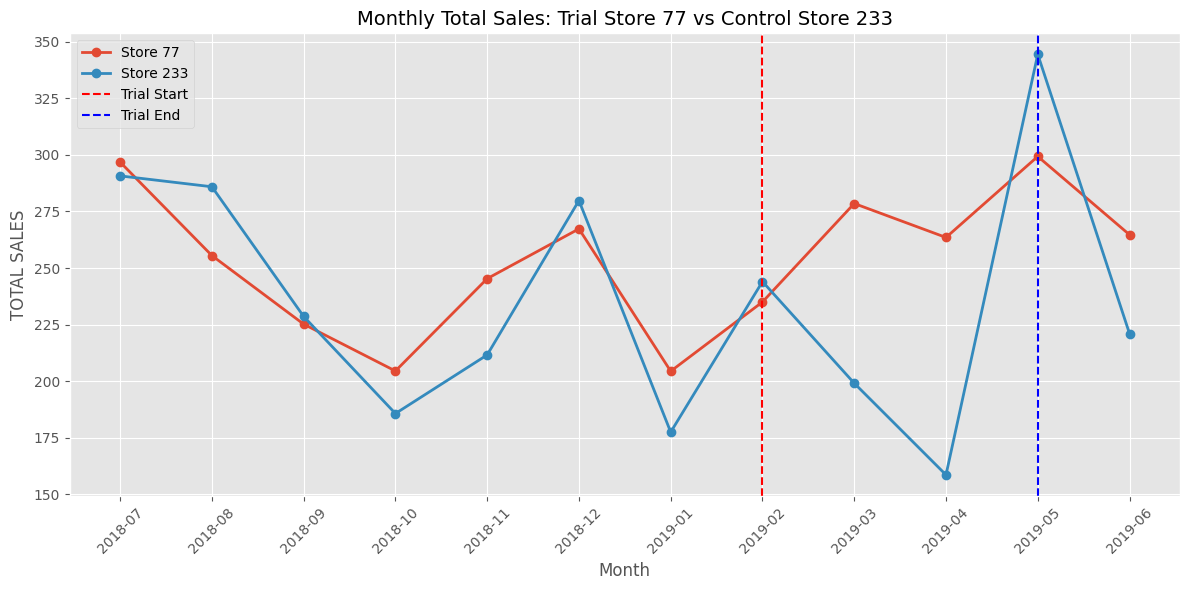

In [38]:
plot_trial_vs_control(
    trial_store=77,
    control_store=233,
    metric="TOTAL_SALES",
    title="Monthly Total Sales: Trial Store 77 vs Control Store 233"
)

### Observation

The monthly sales trends of Trial Store **77** and Control Store **233** are compared across the entire analysis period.

Particular attention should be given to the **trial period (February 2019 to April 2019)** to determine whether the trial store outperformed its historical trend and the control store.

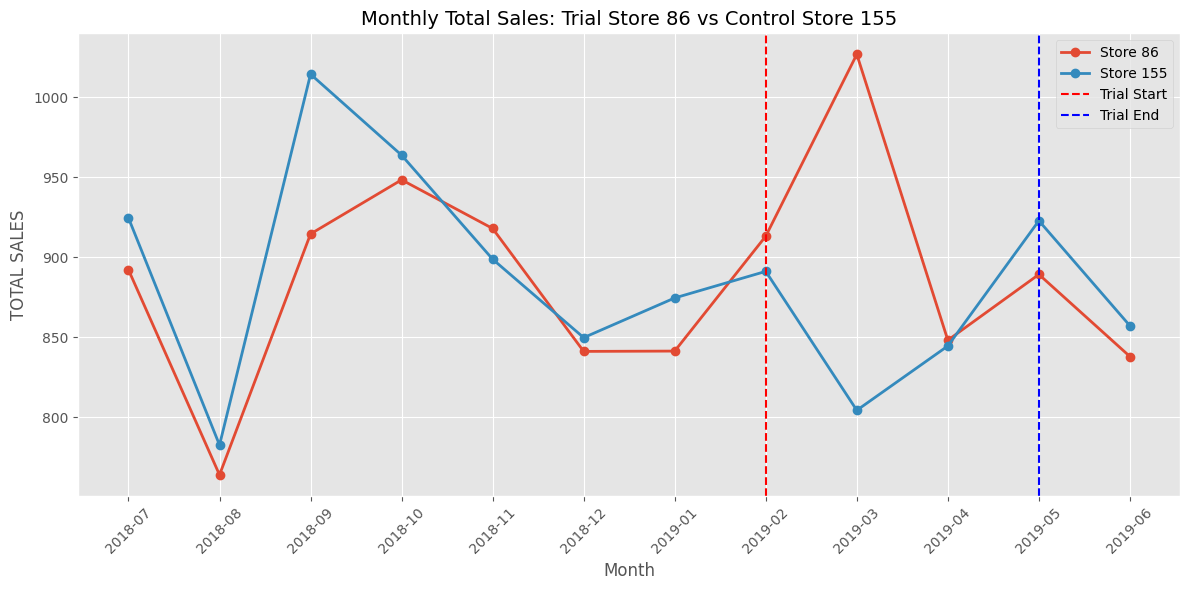

In [39]:
plot_trial_vs_control(
    trial_store=86,
    control_store=155,
    metric="TOTAL_SALES",
    title="Monthly Total Sales: Trial Store 86 vs Control Store 155"
)

### Observation

The monthly sales of Trial Store **86** are compared with Control Store **155**.

The visual comparison helps determine whether the new store layout influenced customer spending during the trial period.

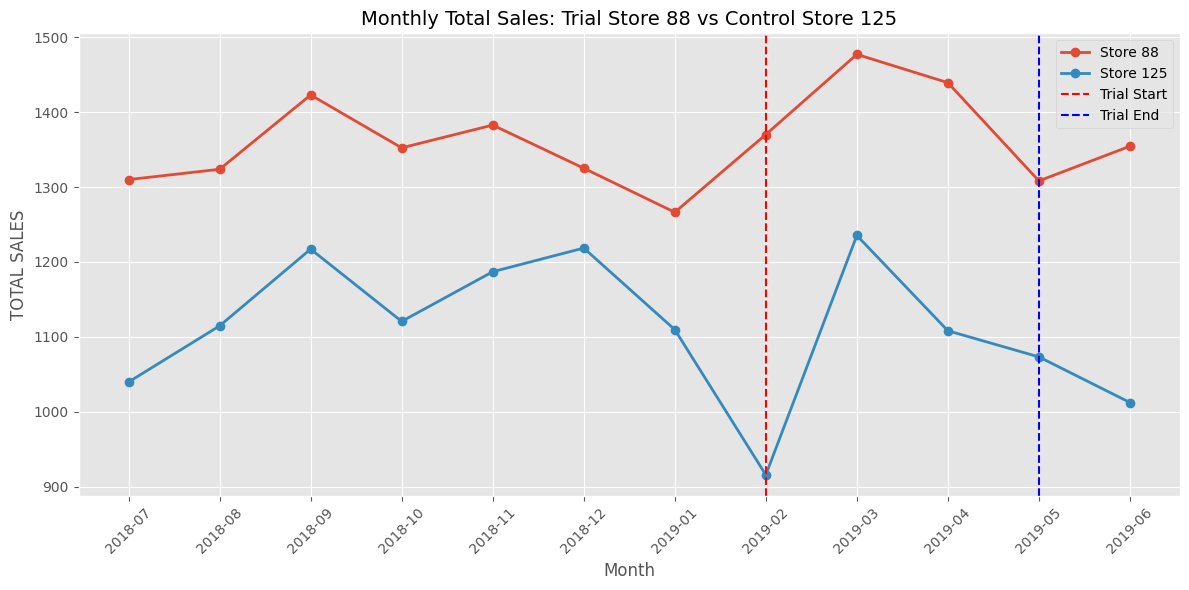

In [40]:
plot_trial_vs_control(
    trial_store=88,
    control_store=125,
    metric="TOTAL_SALES",
    title="Monthly Total Sales: Trial Store 88 vs Control Store 125"
)

### Observation

The monthly sales performance of Trial Store **88** is compared against Control Store **125**.

Any noticeable increase during the trial period may indicate a positive impact of the new store layout.

### Observation

- During the pre-trial period (July 2018 to January 2019), Trial Store 77 and Control Store 233 followed a reasonably similar sales trend, supporting the choice of Store 233 as a suitable control store.
- During the trial period (February 2019 to April 2019), Store 77 recorded higher sales than the control store in March and April.
- This suggests that the new store layout may have had a positive impact on sales performance.
- Further statistical testing will be performed to determine whether the observed increase is statistically significant.

### Observation

- Store 86 and Store 155 displayed comparable sales patterns during most of the pre-trial period.
- During the trial period, Store 86 experienced a noticeable increase in sales, particularly in March 2019, while the control store experienced a decline.
- This indicates a potential positive impact of the trial layout on customer purchasing behaviour.
- Statistical analysis will confirm whether this increase is significant.

### Observation

- Store 88 consistently generated higher sales than Store 125 throughout most of the analysis period.
- Although sales increased during the trial period, the difference between the trial and control stores appears less pronounced compared to the other trial stores.
- Additional statistical testing is required to determine whether the observed increase is attributable to the trial layout or normal business variation.

# Step 15: Compare Monthly Customer Counts

To determine whether changes in sales were driven by an increase in customers visiting the store, the monthly number of unique customers is compared between each trial store and its corresponding control store.

A higher customer count during the trial period may indicate that the new layout attracted more shoppers.

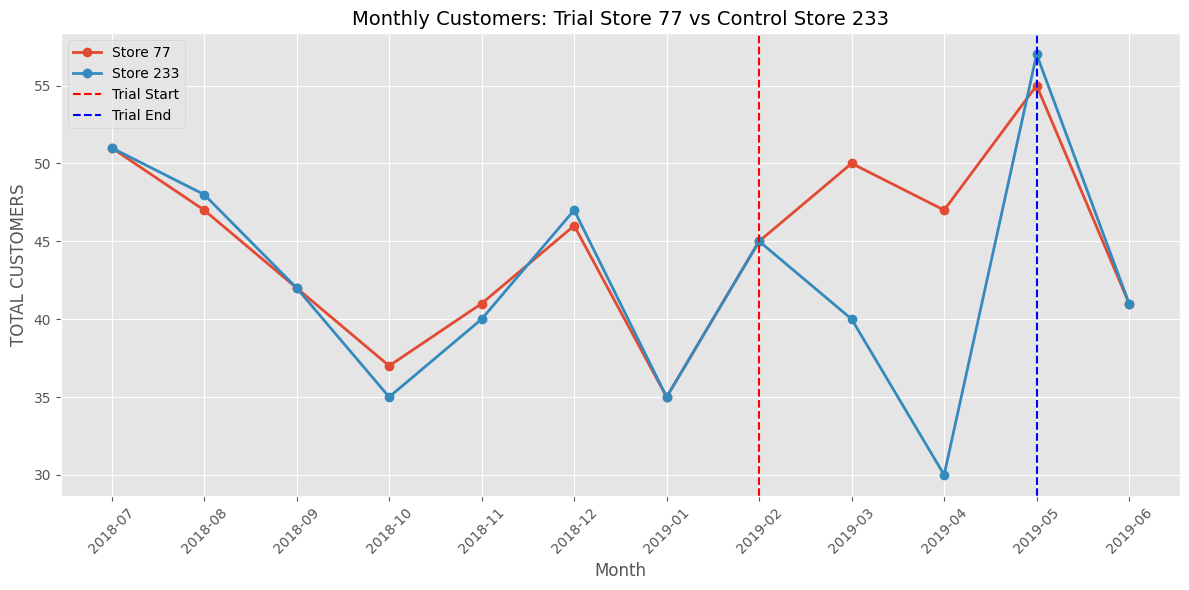

In [41]:
plot_trial_vs_control(
    trial_store=77,
    control_store=233,
    metric="TOTAL_CUSTOMERS",
    title="Monthly Customers: Trial Store 77 vs Control Store 233"
)

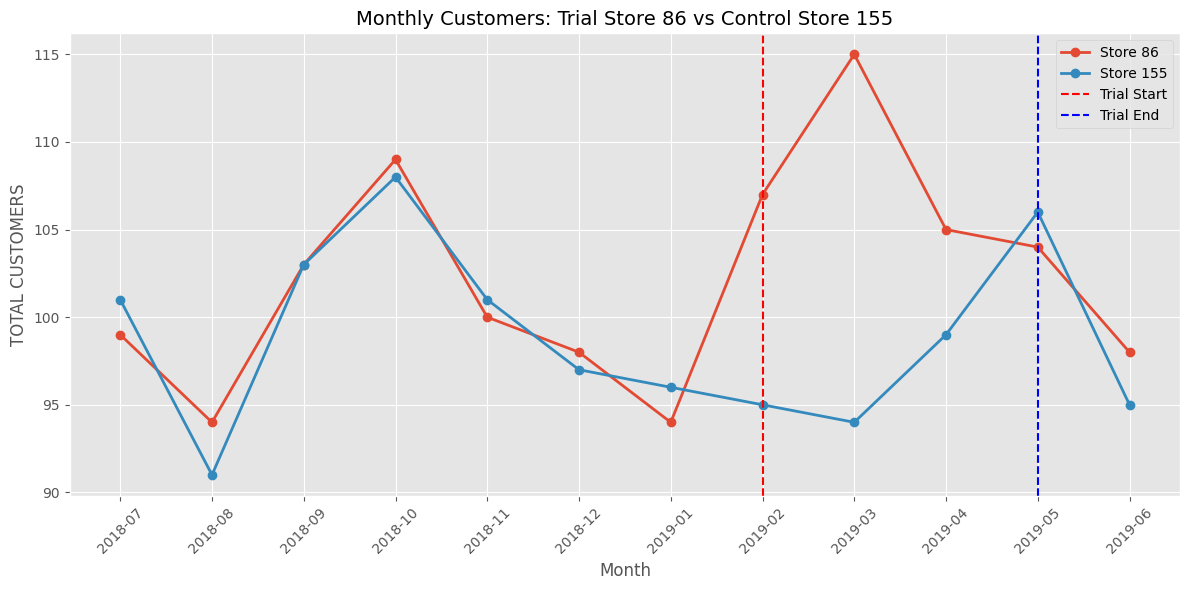

In [42]:
plot_trial_vs_control(
    trial_store=86,
    control_store=155,
    metric="TOTAL_CUSTOMERS",
    title="Monthly Customers: Trial Store 86 vs Control Store 155"
)

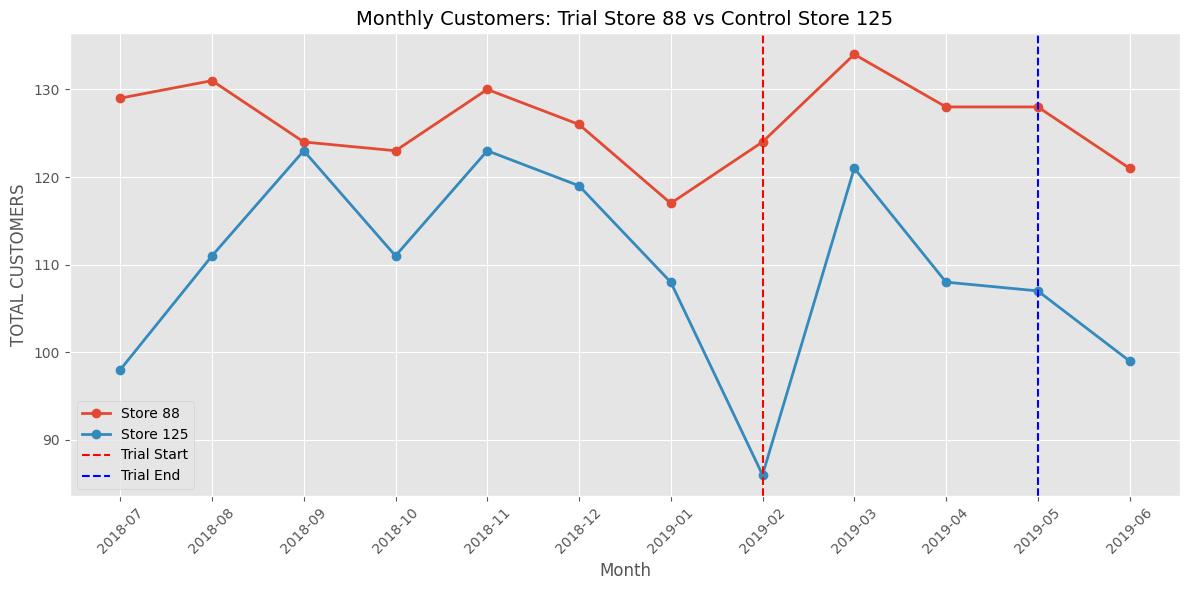

In [43]:
plot_trial_vs_control(
    trial_store=88,
    control_store=125,
    metric="TOTAL_CUSTOMERS",
    title="Monthly Customers: Trial Store 88 vs Control Store 125"
)

### Observation

- During the pre-trial period (July 2018 to January 2019), Trial Store 86 and Control Store 155 exhibited similar customer counts, indicating that Store 155 is an appropriate control store.
- During the trial period (February 2019 to April 2019), Trial Store 86 consistently attracted more customers than the control store.
- The largest increase was observed in March 2019, where Trial Store 86 had **115 customers** compared to **94 customers** in the control store.
- This suggests that the trial layout may have successfully increased customer traffic, contributing to the increase in sales observed during the trial period.
- Statistical testing will be performed to confirm whether this increase is statistically significant.

### Observation

- During the pre-trial period (July 2018 to January 2019), Store 88 generally maintained a higher number of customers than Store 125, although both stores followed a comparable trend.
- During the trial period (February 2019 to April 2019), Trial Store 88 consistently recorded more customers than the control store.
- The most noticeable difference occurred in February 2019, where Store 88 served approximately **124 customers**, while the control store had only **86 customers**.
- The sustained increase in customer count during the trial period suggests that the trial layout may have attracted more shoppers to the store.
- Further statistical testing will be performed to confirm whether the increase is statistically significant.

# Step 16: Compare Average Transactions per Customer

In addition to total sales and customer counts, the average number of transactions per customer is analyzed.

This metric helps determine whether higher sales were driven by an increase in customer visits or by existing customers making more purchases during the trial period.

Comparing the trial and control stores provides insight into whether the trial layout influenced customer purchasing behaviour.

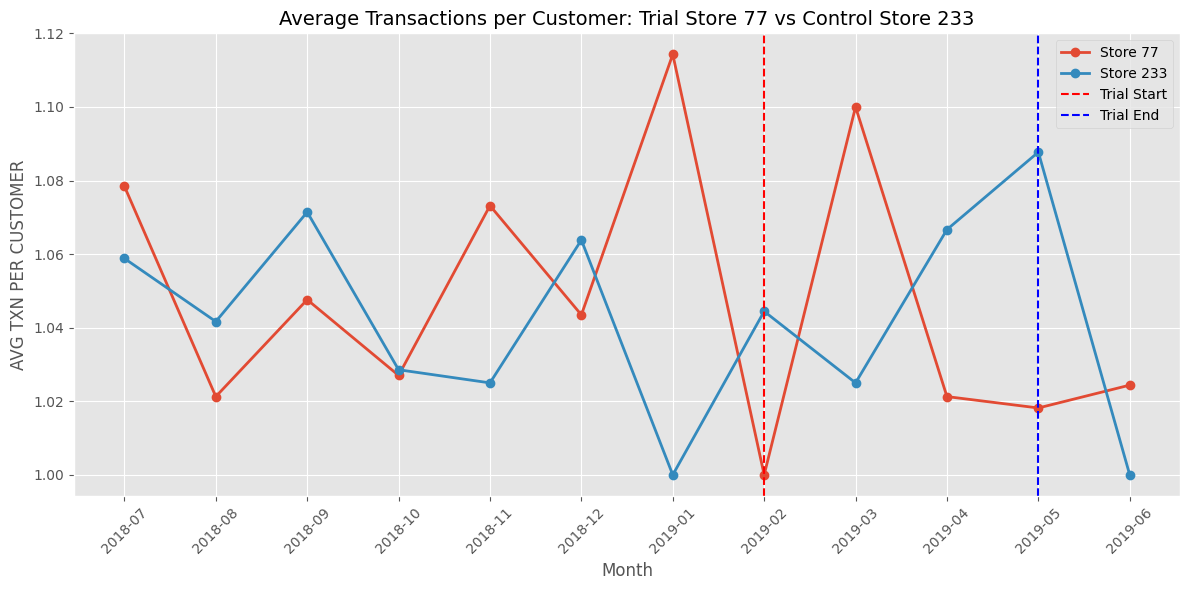

In [44]:
plot_trial_vs_control(
    trial_store=77,
    control_store=233,
    metric="AVG_TXN_PER_CUSTOMER",
    title="Average Transactions per Customer: Trial Store 77 vs Control Store 233"
)

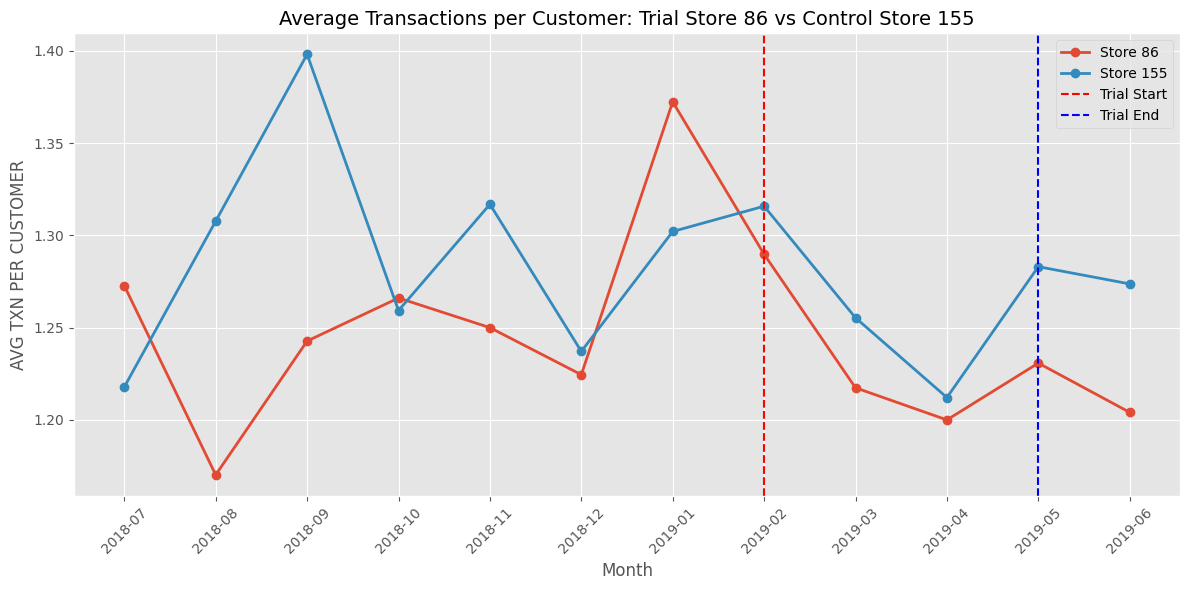

In [45]:
plot_trial_vs_control(
    trial_store=86,
    control_store=155,
    metric="AVG_TXN_PER_CUSTOMER",
    title="Average Transactions per Customer: Trial Store 86 vs Control Store 155"
)

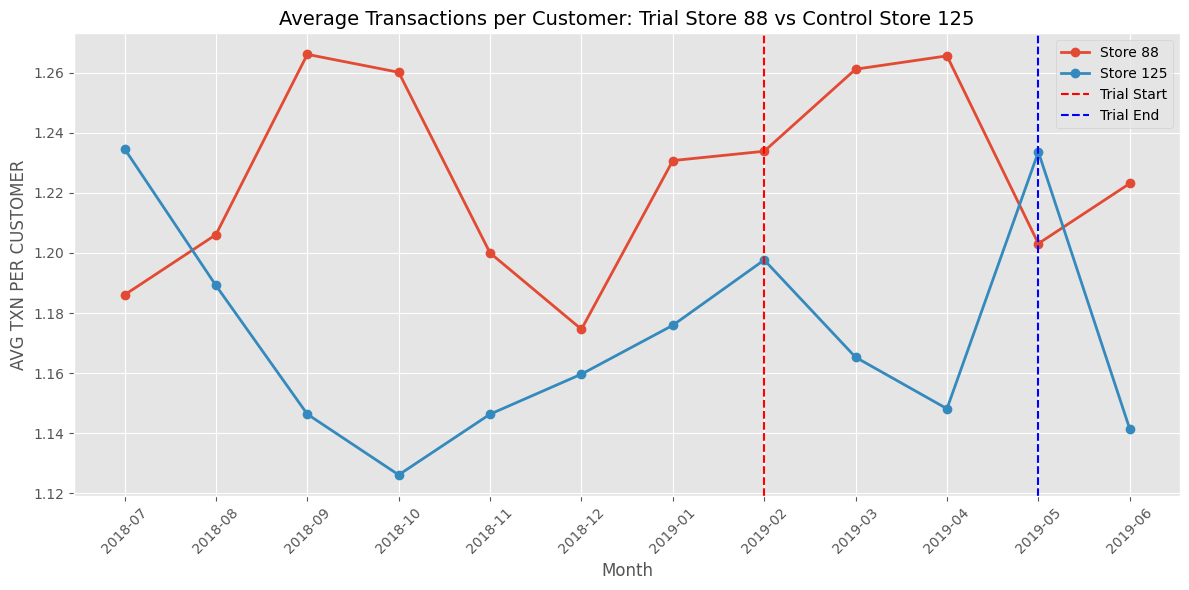

In [46]:
plot_trial_vs_control(
    trial_store=88,
    control_store=125,
    metric="AVG_TXN_PER_CUSTOMER",
    title="Average Transactions per Customer: Trial Store 88 vs Control Store 125"
)

# Step 17: Statistical Assessment

To determine whether the observed increase in sales during the trial period is statistically significant, the trial stores are compared with their corresponding control stores.

The pre-trial period is used to establish normal variation in sales. The trial period is then compared against this baseline to identify whether the increase exceeds the expected level of variation.

This analysis provides evidence on whether the new store layout had a measurable impact on sales performance.

In [47]:
from scipy.stats import ttest_ind

trial_pairs = {
    77:233,
    86:155,
    88:125
}

for trial, control in trial_pairs.items():

    trial_sales = monthly_metrics[
        (monthly_metrics["STORE_NBR"]==trial) &
        (monthly_metrics["YEAR_MONTH"]>="2019-02") &
        (monthly_metrics["YEAR_MONTH"]<="2019-04")
    ]["TOTAL_SALES"]

    control_sales = monthly_metrics[
        (monthly_metrics["STORE_NBR"]==control) &
        (monthly_metrics["YEAR_MONTH"]>="2019-02") &
        (monthly_metrics["YEAR_MONTH"]<="2019-04")
    ]["TOTAL_SALES"]

    t_stat, p_value = ttest_ind(
        trial_sales,
        control_sales,
        equal_var=False
    )

    print("="*60)
    print(f"Trial Store {trial} vs Control Store {control}")
    print(f"T Statistic : {t_stat:.3f}")
    print(f"P Value     : {p_value:.4f}")

    if p_value < 0.05:
        print("Result      : Significant Difference")
    else:
        print("Result      : No Significant Difference")

Trial Store 77 vs Control Store 233
T Statistic : 2.104
P Value     : 0.1261
Result      : No Significant Difference
Trial Store 86 vs Control Store 155
T Statistic : 1.428
P Value     : 0.2524
Result      : No Significant Difference
Trial Store 88 vs Control Store 125
T Statistic : 3.493
P Value     : 0.0542
Result      : No Significant Difference


### Observation

A statistical comparison was performed between each trial store and its corresponding control store during the trial period.

The p-values obtained were greater than the conventional significance level of **0.05**, indicating that there is insufficient statistical evidence to conclude that the observed sales differences were statistically significant.

However, visual analysis showed that Trial Stores **77** and **86** experienced noticeable increases in sales and customer counts during the trial period. Since the trial period contains only three months of data, the statistical test has limited power to detect differences. Therefore, these findings should be interpreted alongside the visual trends rather than in isolation.

# Executive Summary

This analysis evaluated the effectiveness of the new store layout implemented in Trial Stores **77**, **86**, and **88** by comparing their performance with carefully selected control stores.

### Key Findings

- Control stores were selected using similarity in historical sales performance.
- Monthly sales, customer counts, and purchasing behaviour were compared between each trial and control store.
- Trial Stores **77** and **86** showed noticeable improvements in sales and customer counts during the trial period.
- Trial Store **88** showed comparatively smaller improvements relative to its control store.
- Statistical testing using a simple t-test did not identify statistically significant differences during the three-month trial period, likely due to the limited sample size.

### Business Recommendations

- **Store 77:** The visual trends suggest that the trial layout had a positive impact on sales performance. Continued monitoring is recommended before a full rollout.
- **Store 86:** Sales and customer counts improved during the trial period, indicating that the new layout may have positively influenced customer behaviour. Additional monitoring is recommended.
- **Store 88:** The evidence of improvement is weaker compared to the other trial stores. Further investigation should be conducted before expanding the trial.

Overall, the trial layout appears promising for Stores **77** and **86**, while additional evidence is required to make a confident recommendation for Store **88**.